# Baseline Villain Prediction

This notebook trains and compares two PyTorch Geometric baselines for character-level villain prediction.

Models in this notebook:
- `full_baseline`: uses the broader character feature set already present in the extracted graphs
- `evidence_only`: uses only `gender`, `social_status`, `narrative_introduction_timing`, `has_alibi`, `present_at_crime_scene`, and occupation/location/organization context

Important design choices:
- target is binary: `Villain` vs. `not Villain`
- each story becomes one PyG graph
- training/validation/test splits are done by whole story, not by node
- the model is a prebuilt `GraphSAGE` classifier from PyTorch Geometric
- `motive_type` is treated as categorical at load time for the fuller baseline
- the `evidence_only` model removes explicit `kills` edges from the graph before message passing

The goal is to make it easy to compare a stronger baseline against a lower-leakage baseline.

## Runtime Setup

This notebook is written to run either locally or in a Google Colab kernel.

If you are in Colab and the repo is not already present, clone it first and rerun the path-resolution cell.

Example:
```bash
!git clone https://github.com/abmummaneni/290-Final-Project.git /content/290-Final-Project
```


In [1]:
%pip install -q torch torchvision torchaudio torch-geometric pandas scikit-learn matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import json
import math
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GraphSAGE
from torch_geometric.utils import to_undirected
from tqdm.auto import tqdm

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")
print(f"PyTorch version: {torch.__version__}")


Running in Colab: False
PyTorch version: 2.11.0


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

USER_PROJECT_ROOT = None
# Example local path:
# USER_PROJECT_ROOT = "/Users/abhi/ml/290Final"
# Example Colab path:
# USER_PROJECT_ROOT = "/content/290-Final-Project"


def resolve_detective_root(user_project_root: str | None = None) -> Path:
    candidates = []
    if user_project_root:
        candidates.append(Path(user_project_root).expanduser())

    cwd = Path.cwd().resolve()
    candidates.extend(
        [
            cwd,
            cwd.parent,
            Path("/content/290-Final-Project"),
            Path("/content/drive/MyDrive/290-Final-Project"),
        ]
    )

    for base in candidates:
        detective_dir = base / "Detective"
        if (detective_dir / "extraction" / "data" / "graphs").exists():
            return detective_dir
        if (base / "extraction" / "data" / "graphs").exists() and (base / "murder_mystery_graph_schema.md").exists():
            return base

    raise FileNotFoundError(
        "Could not find the Detective project. Clone the repo or set USER_PROJECT_ROOT manually."
    )


DETECTIVE_ROOT = resolve_detective_root(USER_PROJECT_ROOT)
GRAPHS_DIR = DETECTIVE_ROOT / "extraction" / "data" / "graphs"
OUTPUT_DIR = DETECTIVE_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Detective root: {DETECTIVE_ROOT}")
print(f"Graphs dir:     {GRAPHS_DIR}")


Detective root: /Users/abhi/ml/290Final/Detective
Graphs dir:     /Users/abhi/ml/290Final/Detective/extraction/data/graphs


## Data Encoding

The graph JSON files already define one story graph per file. This notebook converts each file into a PyG `Data` object.

Node handling:
- characters, occupations, locations, and organizations are all included as nodes
- only character nodes contribute to the loss
- non-character nodes still provide context through message passing

Feature handling:
- numeric fields stay numeric
- `motive_type` is canonicalized into categories at load time for the fuller model
- the lower-leakage model drops motive-type information entirely

Edge handling:
- both models use homogeneous undirected message passing
- the `evidence_only` model explicitly removes `kills` edges before graph construction


In [4]:
OCCUPATION_FEATURES = ["authority_level", "access_level", "capability_level"]
LOCATION_FEATURES = ["accessibility", "isolability", "evidentiary_value"]
ORGANIZATION_FEATURES = ["institutional_power", "secrecy_level", "financial_scale"]

NODE_TYPE_ORDER = ["character", "occupation", "location", "organization"]
NODE_TYPE_TO_INDEX = {name: idx for idx, name in enumerate(NODE_TYPE_ORDER)}
NODE_TYPE_DIM = len(NODE_TYPE_ORDER)

SCHEMA_MOTIVE_NUMERIC_TO_CATEGORY = {
    -1.0: "UNK",
    0.0: "jealousy",
    0.33: "money",
    0.66: "revenge",
    1.0: "love",
}


def canonicalize_motive_type(raw_value) -> str:
    if raw_value is None:
        return "UNK"
    if isinstance(raw_value, bool):
        return str(raw_value).lower()
    if isinstance(raw_value, (int, float)):
        numeric = round(float(raw_value), 2)
        if numeric in SCHEMA_MOTIVE_NUMERIC_TO_CATEGORY:
            return SCHEMA_MOTIVE_NUMERIC_TO_CATEGORY[numeric]
        return f"NUM_{numeric:g}"
    if isinstance(raw_value, str):
        normalized = raw_value.strip().lower()
        if normalized in {"", "none", "null", "nan", "n/a", "unk", "unknown"}:
            return "UNK"
        return normalized
    return "UNK"


def normalize_numeric_value(value) -> float:
    if value is None:
        return -1.0
    if isinstance(value, bool):
        return float(value)
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        normalized = value.strip().lower()
        if normalized in {"", "none", "null", "nan", "n/a", "unk", "unknown"}:
            return -1.0
        if normalized in {"yes", "true"}:
            return 1.0
        if normalized in {"no", "false"}:
            return 0.0
        try:
            return float(normalized)
        except ValueError:
            return -1.0
    return -1.0


graph_paths = sorted(GRAPHS_DIR.glob("*.json"))
motive_categories = {"UNK"}
for path in graph_paths:
    graph = json.loads(path.read_text(encoding="utf-8"))
    for character in graph.get("characters", []):
        motive_categories.add(canonicalize_motive_type(character.get("features", {}).get("motive_type")))

MOTIVE_CATEGORY_ORDER = sorted(motive_categories)
MOTIVE_CATEGORY_TO_INDEX = {name: idx for idx, name in enumerate(MOTIVE_CATEGORY_ORDER)}
MOTIVE_FEATURE_DIM = len(MOTIVE_CATEGORY_ORDER)

print(f"Observed motive_type categories ({MOTIVE_FEATURE_DIM}): {MOTIVE_CATEGORY_ORDER}")


Observed motive_type categories (15): ['NUM_0.5', 'NUM_0.7', 'UNK', 'entitlement', 'financial', 'glory', 'jealousy', 'love', 'manipulation', 'money', 'other', 'power', 'protecting family', 'psychopathic tendencies', 'revenge']


In [5]:
MODEL_CONFIGS = {
    "full_baseline": {
        "character_numeric_features": [
            "gender",
            "social_status",
            "narrative_introduction_timing",
            "has_alibi",
            "present_at_crime_scene",
            "has_motive",
            "is_concealing_information",
            "has_hidden_relationship",
            "narrative_prominence",
        ],
        "include_motive_type": True,
        "excluded_relations": set(),
        "description": "Broader baseline using the larger feature set and all edges.",
    },
    "evidence_only": {
        "character_numeric_features": [
            "gender",
            "social_status",
            "narrative_introduction_timing",
            "has_alibi",
            "present_at_crime_scene",
        ],
        "include_motive_type": False,
        "excluded_relations": {"kills"},
        "description": "Lower-leakage baseline using only evidence-style character features and no kills edges.",
    },
}

display(pd.DataFrame.from_dict(MODEL_CONFIGS, orient="index")[['description']])


,description
full_baseline,Broader baseline using the larger feature set ...
evidence_only,Lower-leakage baseline using only evidence-sty...


In [6]:
def node_type_one_hot(node_type: str) -> list[float]:
    vector = [0.0] * NODE_TYPE_DIM
    vector[NODE_TYPE_TO_INDEX[node_type]] = 1.0
    return vector


def motive_one_hot(raw_value) -> list[float]:
    category = canonicalize_motive_type(raw_value)
    vector = [0.0] * MOTIVE_FEATURE_DIM
    vector[MOTIVE_CATEGORY_TO_INDEX[category]] = 1.0
    return vector


def character_feature_vector(raw_features: dict, config: dict) -> list[float]:
    vector = [normalize_numeric_value(raw_features.get(name, -1.0)) for name in config['character_numeric_features']]
    if config['include_motive_type']:
        vector.extend(motive_one_hot(raw_features.get('motive_type')))
    return vector


def padded_aux_features(raw_features: dict, feature_names: list[str], config: dict) -> list[float]:
    char_numeric_dim = len(config['character_numeric_features'])
    values = [normalize_numeric_value(raw_features.get(name, -1.0)) for name in feature_names]
    values.extend([-1.0] * (char_numeric_dim - len(values)))
    if config['include_motive_type']:
        values.extend([0.0] * MOTIVE_FEATURE_DIM)
    return values


def input_dim_for_config(config: dict) -> int:
    dim = len(config['character_numeric_features']) + NODE_TYPE_DIM
    if config['include_motive_type']:
        dim += MOTIVE_FEATURE_DIM
    return dim


def build_graph_example(path: Path, config_name: str, config: dict) -> tuple[Data, dict]:
    graph = json.loads(path.read_text(encoding='utf-8'))
    metadata = graph.get('metadata', {})

    node_rows = []
    node_id_to_index = {}
    node_types = []
    labels = []
    target_mask = []

    character_names = []
    character_indices = []
    character_text_labels = []
    character_motive_categories = []

    def add_nodes(items: list[dict], node_type: str, feature_builder):
        for item in items:
            node_index = len(node_rows)
            node_id_to_index[item['id']] = node_index
            node_types.append(node_type)

            feature_vector = feature_builder(item.get('features', {}))
            feature_vector.extend(node_type_one_hot(node_type))
            node_rows.append(feature_vector)

            if node_type == 'character':
                raw_label = item.get('label', 'UNK')
                labels.append(1.0 if raw_label == 'Villain' else 0.0)
                target_mask.append(raw_label != 'UNK')
                character_names.append(item.get('name', item['id']))
                character_indices.append(node_index)
                character_text_labels.append(raw_label)
                character_motive_categories.append(canonicalize_motive_type(item.get('features', {}).get('motive_type')))
            else:
                labels.append(-100.0)
                target_mask.append(False)

    add_nodes(graph.get('characters', []), 'character', lambda features: character_feature_vector(features, config))
    add_nodes(graph.get('occupations', []), 'occupation', lambda features: padded_aux_features(features, OCCUPATION_FEATURES, config))
    add_nodes(graph.get('locations', []), 'location', lambda features: padded_aux_features(features, LOCATION_FEATURES, config))
    add_nodes(graph.get('organizations', []), 'organization', lambda features: padded_aux_features(features, ORGANIZATION_FEATURES, config))

    edges = []
    filtered_relation_count = Counter()
    for edge in graph.get('edges', []):
        relation = str(edge.get('relation', '')).strip().lower()
        if relation in config['excluded_relations']:
            filtered_relation_count[relation] += 1
            continue
        source = node_id_to_index.get(edge.get('source'))
        target = node_id_to_index.get(edge.get('target'))
        if source is None or target is None:
            continue
        edges.append((source, target))

    if edges:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_index = to_undirected(edge_index, num_nodes=len(node_rows))
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)

    data = Data(
        x=torch.tensor(node_rows, dtype=torch.float32),
        edge_index=edge_index,
        y=torch.tensor(labels, dtype=torch.float32),
        target_mask=torch.tensor(target_mask, dtype=torch.bool),
        node_type=torch.tensor([NODE_TYPE_TO_INDEX[name] for name in node_types], dtype=torch.long),
    )

    summary = {
        'config_name': config_name,
        'entry_id': metadata.get('entry_id', path.stem),
        'title': metadata.get('title', path.stem),
        'medium': metadata.get('medium', 'Unknown'),
        'year': metadata.get('year', np.nan),
        'num_nodes': len(node_rows),
        'num_edges': int(edge_index.size(1)),
        'num_characters': len(character_names),
        'num_target_characters': int(sum(target_mask)),
        'num_villains': int(sum(label == 'Villain' for label in character_text_labels)),
        'num_filtered_edges': int(sum(filtered_relation_count.values())),
        'character_names': character_names,
        'character_indices': character_indices,
        'character_labels': character_text_labels,
        'character_motive_categories': character_motive_categories,
    }
    return data, summary


datasets_by_config = {}
summaries_by_config = {}
for config_name, config in MODEL_CONFIGS.items():
    dataset = []
    summaries = []
    for path in graph_paths:
        data, summary = build_graph_example(path, config_name, config)
        if int(data.target_mask.sum()) == 0:
            continue
        dataset.append(data)
        summaries.append(summary)
    datasets_by_config[config_name] = dataset
    summaries_by_config[config_name] = pd.DataFrame(summaries)

for config_name, df in summaries_by_config.items():
    print(config_name, len(df), 'graphs')


full_baseline 576 graphs
evidence_only 576 graphs


## Dataset Summary

The tables below help sanity-check the constructed graphs. In particular, compare the edge counts between the two models to verify that the `evidence_only` model is actually removing `kills` edges.

In [7]:
for config_name, df in summaries_by_config.items():
    print(f'\n=== {config_name} ===')
    display(df[['num_nodes', 'num_edges', 'num_characters', 'num_target_characters', 'num_villains', 'num_filtered_edges']].describe().transpose().round(2))

motive_counter = Counter()
for motive_list in summaries_by_config['full_baseline']['character_motive_categories']:
    motive_counter.update(motive_list)
display(pd.Series(motive_counter, name='count').sort_values(ascending=False).rename_axis('motive_type').reset_index())



=== full_baseline ===


,count,mean,std,min,25%,50%,75%,max
num_nodes,576.0,24.34,9.66,6.0,17.0,23.0,30.0,72.0
num_edges,576.0,45.25,19.48,10.0,32.0,41.5,54.0,168.0
num_characters,576.0,10.26,5.16,3.0,7.0,9.0,12.0,45.0
num_target_characters,576.0,10.14,5.19,3.0,7.0,9.0,12.0,45.0
num_villains,576.0,2.31,1.65,0.0,1.0,2.0,3.0,14.0
num_filtered_edges,576.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0



=== evidence_only ===


,count,mean,std,min,25%,50%,75%,max
num_nodes,576.0,24.34,9.66,6.0,17.0,23.0,30.0,72.0
num_edges,576.0,44.45,19.26,10.0,30.0,40.0,54.0,168.0
num_characters,576.0,10.26,5.16,3.0,7.0,9.0,12.0,45.0
num_target_characters,576.0,10.14,5.19,3.0,7.0,9.0,12.0,45.0
num_villains,576.0,2.31,1.65,0.0,1.0,2.0,3.0,14.0
num_filtered_edges,576.0,0.96,3.55,0.0,0.0,0.0,1.0,80.0


,motive_type,count
0,UNK,5054
1,money,505
2,revenge,257
3,love,42
4,jealousy,23
5,power,9
6,NUM_0.5,7
7,other,2
8,NUM_0.7,2
9,financial,1


In [8]:
# Split by story once and reuse the same split for both models.
reference_df = summaries_by_config['full_baseline'].reset_index(drop=True)
all_indices = np.arange(len(reference_df))
stratify_labels = reference_df['medium'].to_numpy()

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_labels,
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=stratify_labels[temp_idx],
)

print(f'Train graphs: {len(train_idx)}')
print(f'Val graphs:   {len(val_idx)}')
print(f'Test graphs:  {len(test_idx)}')


Train graphs: 403
Val graphs:   86
Test graphs:  87


## Model and Training Loop

Both models use the same training code.

Architecture:
- `GraphSAGE` message-passing backbone
- one linear output head producing one logit per node

Loss:
- `BCEWithLogitsLoss`
- computed only on masked character nodes
- uses `pos_weight` to compensate for the class imbalance between villains and non-villains

Model selection:
- early stopping based on validation average precision
- best validation checkpoint is restored before test evaluation


In [9]:
BATCH_SIZE = 32
HIDDEN_DIM = 64
NUM_LAYERS = 3
DROPOUT = 0.25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 40
PATIENCE = 8

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


class VillainGraphSAGE(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, num_layers: int, dropout: float):
        super().__init__()
        self.backbone = GraphSAGE(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            num_layers=num_layers,
            out_channels=hidden_channels,
            dropout=dropout,
        )
        self.classifier = nn.Linear(hidden_channels, 1)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        embeddings = self.backbone(x, edge_index)
        # One scalar per node: positive means more villain-like.
        return self.classifier(embeddings).squeeze(-1)


def target_tensor(graphs: list[Data]) -> torch.Tensor:
    values = [graph.y[graph.target_mask] for graph in graphs]
    return torch.cat(values, dim=0)


def collect_predictions(model: nn.Module, loader: DataLoader, criterion, device: torch.device) -> tuple[np.ndarray, np.ndarray, float]:
    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index)
            mask = batch.target_mask
            if int(mask.sum()) == 0:
                continue
            labels = batch.y[mask]
            masked_logits = logits[mask]
            loss = criterion(masked_logits, labels)
            probs = torch.sigmoid(masked_logits)

            total_loss += float(loss.item()) * int(mask.sum())
            total_examples += int(mask.sum())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    if not all_probs:
        return np.array([]), np.array([]), math.nan

    probs_np = torch.cat(all_probs).numpy()
    labels_np = torch.cat(all_labels).numpy().astype(int)
    avg_loss = total_loss / max(total_examples, 1)
    return probs_np, labels_np, avg_loss


def metric_dict(probs: np.ndarray, labels: np.ndarray, loss_value: float) -> dict:
    if probs.size == 0:
        return {'loss': loss_value, 'accuracy': math.nan, 'precision': math.nan, 'recall': math.nan, 'f1': math.nan, 'roc_auc': math.nan, 'average_precision': math.nan}
    preds = (probs >= 0.5).astype(int)
    metrics = {
        'loss': loss_value,
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0),
    }
    if len(np.unique(labels)) > 1:
        metrics['roc_auc'] = roc_auc_score(labels, probs)
        metrics['average_precision'] = average_precision_score(labels, probs)
    else:
        metrics['roc_auc'] = math.nan
        metrics['average_precision'] = math.nan
    return metrics


def evaluate_loader(model: nn.Module, loader: DataLoader, criterion, device: torch.device) -> dict:
    probs, labels, loss_value = collect_predictions(model, loader, criterion, device)
    return metric_dict(probs, labels, loss_value)


def train_one_epoch(model: nn.Module, loader: DataLoader, criterion, optimizer, device: torch.device) -> float:
    model.train()
    total_loss = 0.0
    total_examples = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index)
        mask = batch.target_mask
        if int(mask.sum()) == 0:
            continue
        labels = batch.y[mask]
        loss = criterion(logits[mask], labels)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * int(mask.sum())
        total_examples += int(mask.sum())

    return total_loss / max(total_examples, 1)


def train_model(config_name: str) -> dict:
    config = MODEL_CONFIGS[config_name]
    dataset = datasets_by_config[config_name]
    summary_df = summaries_by_config[config_name].reset_index(drop=True)

    train_graphs = [dataset[i] for i in train_idx]
    val_graphs = [dataset[i] for i in val_idx]
    test_graphs = [dataset[i] for i in test_idx]

    train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

    train_targets = target_tensor(train_graphs)
    positive_count = float(train_targets.sum().item())
    negative_count = float(train_targets.numel() - positive_count)
    pos_weight_value = negative_count / max(positive_count, 1.0)

    model = VillainGraphSAGE(
        in_channels=input_dim_for_config(config),
        hidden_channels=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_value, device=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    history = []
    best_state = None
    best_val_ap = -float('inf')
    epochs_without_improvement = 0

    for epoch in tqdm(range(1, MAX_EPOCHS + 1), desc=f'Training {config_name}'):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        train_metrics = evaluate_loader(model, train_loader, criterion, device)
        val_metrics = evaluate_loader(model, val_loader, criterion, device)

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_f1': train_metrics['f1'],
            'train_ap': train_metrics['average_precision'],
            'val_loss': val_metrics['loss'],
            'val_f1': val_metrics['f1'],
            'val_ap': val_metrics['average_precision'],
            'val_roc_auc': val_metrics['roc_auc'],
        })

        score = val_metrics['average_precision']
        if not math.isnan(score) and score > best_val_ap:
            best_val_ap = score
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"{config_name} | epoch {epoch:02d} | train_loss={train_loss:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} | val_f1={val_metrics['f1']:.4f} | val_ap={val_metrics['average_precision']:.4f}"
            )

        if epochs_without_improvement >= PATIENCE:
            print(f'{config_name}: early stopping after {epoch} epochs.')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    val_results = evaluate_loader(model, val_loader, criterion, device)
    test_results = evaluate_loader(model, test_loader, criterion, device)
    history_df = pd.DataFrame(history)

    checkpoint_path = OUTPUT_DIR / f'{config_name}_villain_graphsage.pt'
    torch.save({
        'model_state_dict': model.state_dict(),
        'config_name': config_name,
        'config': config,
        'input_dim': input_dim_for_config(config),
        'motive_categories': MOTIVE_CATEGORY_ORDER,
        'val_metrics': val_results,
        'test_metrics': test_results,
    }, checkpoint_path)

    return {
        'model': model,
        'criterion': criterion,
        'history_df': history_df,
        'val_results': val_results,
        'test_results': test_results,
        'checkpoint_path': checkpoint_path,
        'summary_df': summary_df,
        'test_graphs': test_graphs,
        'test_loader': test_loader,
    }


Using device: cpu


In [10]:
results_by_model = {}
for config_name in MODEL_CONFIGS:
    results_by_model[config_name] = train_model(config_name)

comparison_df = pd.DataFrame(
    {
        config_name: results['test_results']
        for config_name, results in results_by_model.items()
    }
).T.round(4)
display(comparison_df)


Training full_baseline:   0%|          | 0/40 [00:00<?, ?it/s]

full_baseline | epoch 01 | train_loss=1.0331 | val_loss=0.9436 | val_f1=0.5860 | val_ap=0.7469


full_baseline | epoch 05 | train_loss=0.6431 | val_loss=0.6263 | val_f1=0.6909 | val_ap=0.7603


full_baseline | epoch 10 | train_loss=0.5762 | val_loss=0.5919 | val_f1=0.6914 | val_ap=0.7975


full_baseline | epoch 15 | train_loss=0.5414 | val_loss=0.5826 | val_f1=0.7234 | val_ap=0.8119


...

evidence_only | epoch 25 | train_loss=0.8426 | val_loss=0.8754 | val_f1=0.5469 | val_ap=0.5654


evidence_only | epoch 30 | train_loss=0.8296 | val_loss=0.8577 | val_f1=0.5762 | val_ap=0.5835


evidence_only | epoch 35 | train_loss=0.8358 | val_loss=0.8588 | val_f1=0.5703 | val_ap=0.5951


evidence_only | epoch 40 | train_loss=0.7997 | val_loss=0.8685 | val_f1=0.5414 | val_ap=0.5908


,loss,accuracy,precision,recall,f1,roc_auc,average_precision
full_baseline,0.6266,0.8496,0.6598,0.7361,0.6958,0.9047,0.7848
evidence_only,0.8510,0.6548,0.3863,0.8102,0.5232,0.7942,0.5471


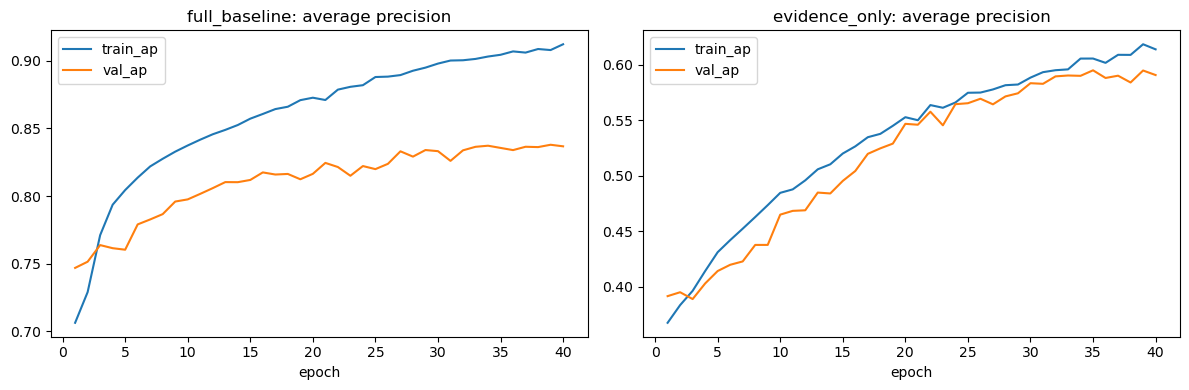

In [11]:
fig, axes = plt.subplots(1, len(results_by_model), figsize=(6 * len(results_by_model), 4), squeeze=False)
for ax, (config_name, results) in zip(axes[0], results_by_model.items()):
    history_df = results['history_df']
    history_df.plot(x='epoch', y=['train_ap', 'val_ap'], ax=ax, title=f'{config_name}: average precision')
plt.tight_layout()
plt.show()


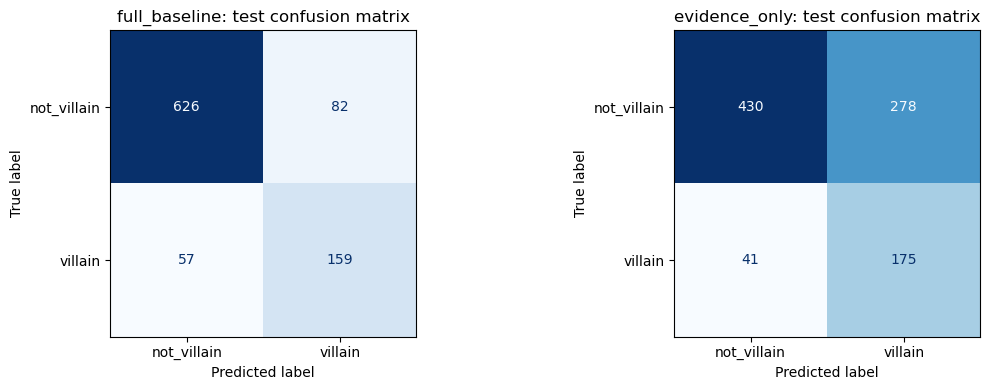

In [12]:
fig, axes = plt.subplots(1, len(results_by_model), figsize=(6 * len(results_by_model), 4), squeeze=False)
for ax, (config_name, results) in zip(axes[0], results_by_model.items()):
    criterion = results['criterion']
    test_probs, test_labels, _ = collect_predictions(results['model'], results['test_loader'], criterion, device)
    test_preds = (test_probs >= 0.5).astype(int)
    cm = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not_villain', 'villain']).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'{config_name}: test confusion matrix')
plt.tight_layout()
plt.show()


## Inspect One Held-Out Story

The next cell compares per-character villain scores for both models on the same test story.

In [13]:
example_index = test_idx[0]
example_rows = []

for config_name, results in results_by_model.items():
    dataset = datasets_by_config[config_name]
    summary_df = summaries_by_config[config_name].reset_index(drop=True)
    example_graph = dataset[example_index].to(device)
    example_summary = summary_df.iloc[example_index]

    results['model'].eval()
    with torch.no_grad():
        logits = results['model'](example_graph.x, example_graph.edge_index).cpu()
        probs = torch.sigmoid(logits).numpy()

    for node_index, character_name, label_text, motive_category in zip(
        example_summary['character_indices'],
        example_summary['character_names'],
        example_summary['character_labels'],
        example_summary['character_motive_categories'],
    ):
        example_rows.append({
            'model': config_name,
            'entry_id': example_summary['entry_id'],
            'title': example_summary['title'],
            'character': character_name,
            'true_label': label_text,
            'motive_type': motive_category,
            'villain_probability': float(probs[node_index]),
        })

example_df = pd.DataFrame(example_rows).sort_values(['model', 'villain_probability'], ascending=[True, False])
print(f"Example graph: {example_df.iloc[0]['entry_id']} - {example_df.iloc[0]['title']}")
display(example_df)


Example graph: TVE_061 - Poirot: After the Funeral


,model,entry_id,title,character,true_label,motive_type,villain_probability
15,evidence_only,TVE_061,Poirot: After the Funeral,Cora Lansquenet,Villain,money,0.655498
16,evidence_only,TVE_061,Poirot: After the Funeral,Miss Gilchrist,Victim,UNK,0.618396
14,evidence_only,TVE_061,Poirot: After the Funeral,Richard Abernethie,Victim,UNK,0.584354
17,evidence_only,TVE_061,Poirot: After the Funeral,Maude Abernethie,Uninvolved,UNK,0.373025
18,evidence_only,TVE_061,Poirot: After the Funeral,Timothy Abernethie,Uninvolved,UNK,0.373025
19,evidence_only,TVE_061,Poirot: After the Funeral,George Crossfield,Witness,UNK,0.210751
26,evidence_only,TVE_061,Poirot: After the Funeral,Mr. Entwhistle,Uninvolved,UNK,0.153169
24,evidence_only,TVE_061,Poirot: After the Funeral,Helen Abernethie,Witness,UNK,0.142331
20,evidence_only,TVE_061,Poirot: After the Funeral,Rosamund Shane,Uninvolved,UNK,0.070759
27,evidence_only,TVE_061,Poirot: After the Funeral,Hercule Poirot,Uninvolved,UNK,0.049993
